## 1. Setup and Data Loading

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def load_hmd_mx(filepath):
    # Load HMD Mx file (1x1) skipping headers
    df = pd.read_csv(filepath, skiprows=2, sep='\s+')
    
    # Handle '110+' age group
    df['Age'] = df['Age'].astype(str).str.replace('+', '', regex=False).astype(int)
    
    # Convert rates to numeric
    for col in ['Female', 'Male', 'Total']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    return df.dropna(subset=['Total'])

# Load Swiss data
df = load_hmd_mx('../data/Mx_1x1.txt')

# Filter for Switzerland modern era (post-1950) 
# Age limited to 95 to remove extreme volatility in centenarians
df_clean = df[(df['Year'] >= 1950) & (df['Age'] <= 95)].copy()

## 2. Matrix Transformation & Visualization

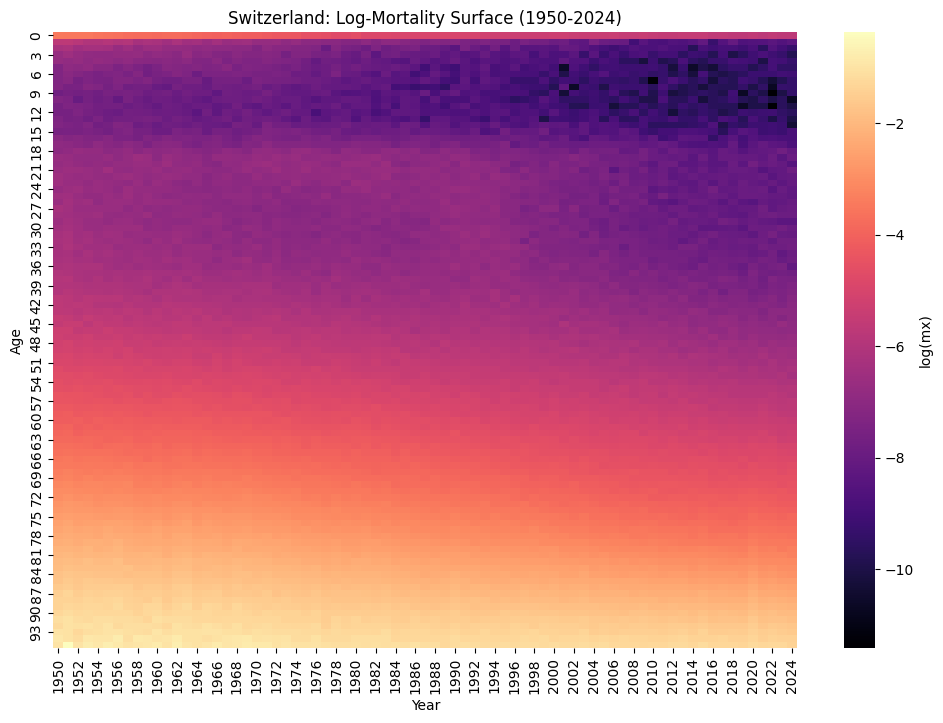

In [7]:
# Create mortality matrix (Age x Year)
mx_matrix = df_clean.pivot(index='Age', columns='Year', values='Total')

# Replace 0 values to avoid log errors and transform
mx_matrix = mx_matrix.replace(0, 1e-8)
log_mx = np.log(mx_matrix)

# Plot Lexis Surface
plt.figure(figsize=(12, 8))
sns.heatmap(log_mx, cmap='magma', cbar_kws={'label': 'log(mx)'})
plt.title('Switzerland: Log-Mortality Surface (1950-2024)')
plt.xlabel('Year')
plt.ylabel('Age')
plt.savefig('../reports/figures/01_mortality_surface.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Lee-Carter Estimation (SVD)

In [8]:
# 1. Compute alpha_x: average log-mortality profile
alpha_x = log_mx.mean(axis=1)

# 2. Center the log-mortality matrix (Z)
Z = log_mx.sub(alpha_x, axis=0)

# 3. Singular Value Decomposition (SVD)
U, S, Vh = np.linalg.svd(Z, full_matrices=False)

# 4. Extract LC parameters (First Principal Component)
# bx: age sensitivity (normalized to sum to 1)
# kt: time trend (mortality index)
bx = U[:, 0] / U[:, 0].sum()
kt = Vh[0, :] * S[0] * U[:, 0].sum()

# Align signs: kt should decrease over time as mortality improves
if kt[0] < kt[-1]:
    kt, bx = -kt, -bx

## 4. Parameter Visualization

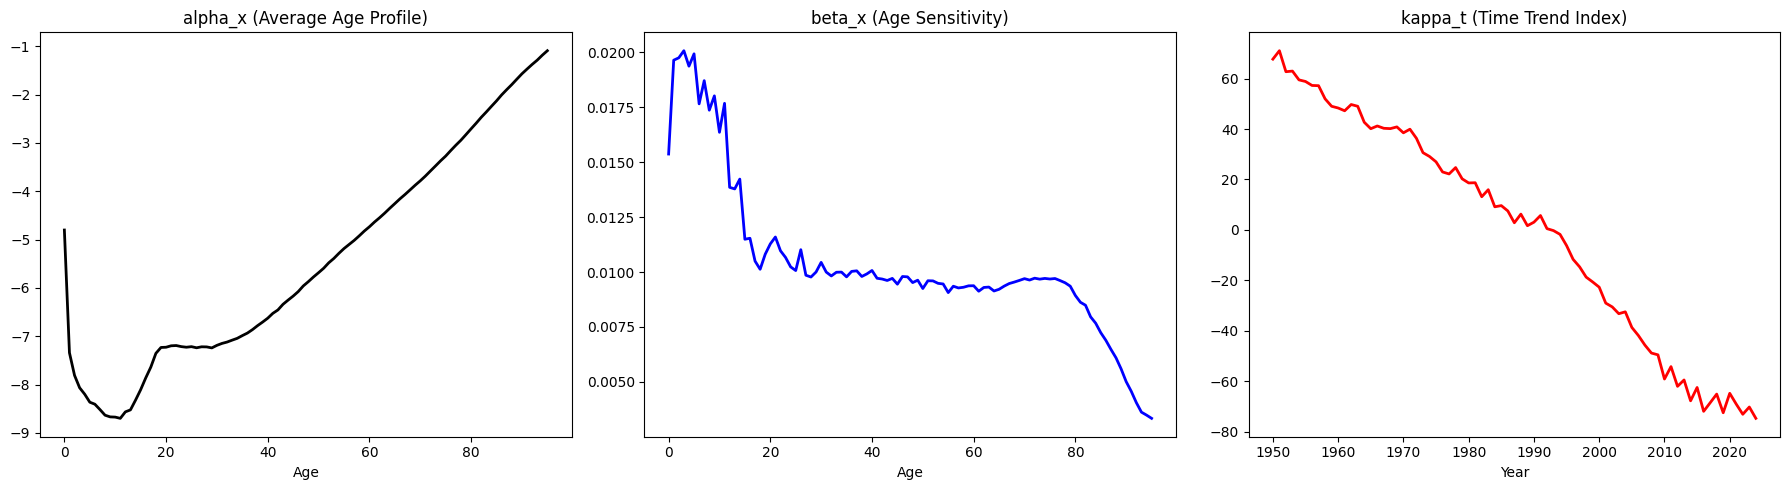

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Average age profile
ax[0].plot(alpha_x.index, alpha_x.values, color='black', lw=2)
ax[0].set_title('alpha_x (Average Age Profile)')
ax[0].set_xlabel('Age')

# Age sensitivity to the trend
ax[1].plot(alpha_x.index, bx, color='blue', lw=2)
ax[1].set_title('beta_x (Age Sensitivity)')
ax[1].set_xlabel('Age')

# Mortality trend over time
ax[2].plot(mx_matrix.columns, kt, color='red', lw=2)
ax[2].set_title('kappa_t (Time Trend Index)')
ax[2].set_xlabel('Year')

plt.tight_layout()
plt.savefig('../reports/figures/02_lc_parameters.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Residual Diagnostics

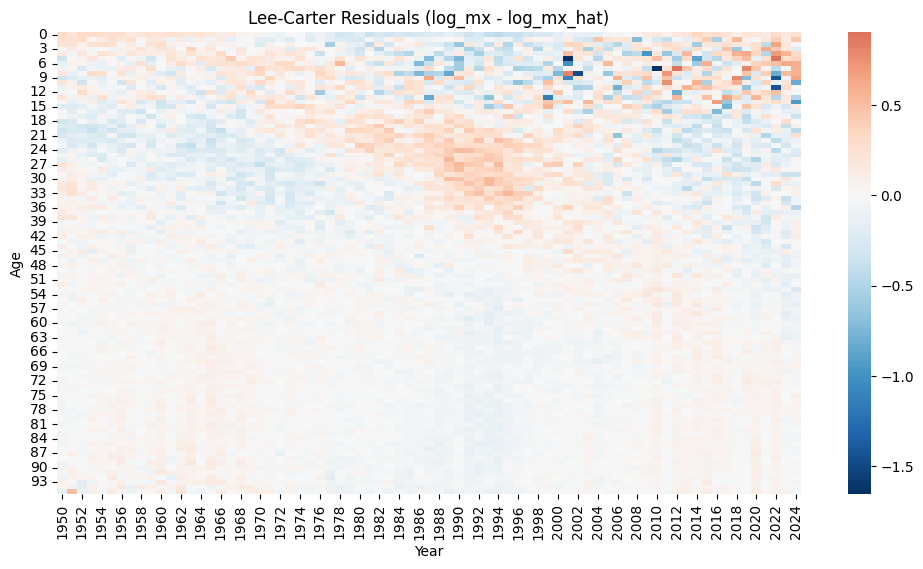

In [10]:
# Reconstruct log-mortality from estimated parameters
log_mx_hat = alpha_x.values[:, None] + bx[:, None] * kt[None, :]
residuals = log_mx - log_mx_hat

# Plot residuals heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(residuals, cmap='RdBu_r', center=0)
plt.title('Lee-Carter Residuals (log_mx - log_mx_hat)')
plt.xlabel('Year')
plt.ylabel('Age')
plt.savefig('../reports/figures/03_lc_residuals.png', dpi=300, bbox_inches='tight')
plt.show()